# Proyek Data Mining: Sistem Rekomendasi Buku (Hybrid Filtering)

## 1. Business Understanding

Mencari judul buku yang ada saat ini seringkali justru membuat bingung, Karna Sering kali kita menemukan rekomendasi buku yang tidak sesuai dengan minat kita. Berangkat dari masalah tersebut, sistem rekomendasi ini dibangun dengan satu misi sederhana: menjadi asisten pribadi yang membantu pembaca menemukan buku yang benar-benar pas dengan minat mereka, tanpa harus repot menyaring puluhan ribu pilihan secara manual.

Untuk mewujudkannya, proyek ini mengolah Book Recommendation Dataset dari Kaggle. Fokus utamanya adalah meracik sebuah sistem Hybrid Filtering yang mampu menjawab beberapa tantangan teknis di lapangan. Secara spesifik, kita akan mengeksplorasi beberapa hal berikut:
- Bagaimana cara merekomendasikan buku dengan mencocokkan atribut bawaannya (seperti nama penulis dan penerbit) melalui pendekatan **Content-Based Filtering**?
- Bagaimana cara memetakan perilaku audiens dan pola *rating* pengguna lain melalui **Collaborative Filtering** untuk memberikan rekomendasi berdasarkan orang-orang dengan selera bacaan yang mirip?
- Bagaimana cara mengintegrasikan kedua teknik tersebut menjadi sebuah arsitektur **Hybrid Filtering** untuk saling menutupi kelemahan masing-masing metode tunggal?
- Bagaimana pendekatan ganda ini dapat meminimalkan kendala teknis seperti masalah *cold-start* (saat data interaksi pengguna masih sangat minim) sekaligus mencegah munculnya daftar rekomendasi yang itu-itu saja?



## 2. Data Understanding
Sebelum melakukan manipulasi, kita wajib menginspeksi skema, tipe data, serta wujud sampel dari ketiga tabel pembentuk dataset ini.

In [1]:
# 1. INSPEKSI TABEL BUKU (Books.csv)
print("=== A. SKEMA & STRUKTUR TABEL BUKU ===")
print("Jumlah Baris & Kolom:", books.shape)
display(books.head(2))
print("\nTipe Data Kolom Buku:\n", books.dtypes)

# 2. INSPEKSI TABEL RATING (Ratings.csv)
print("\n=== B. SKEMA & STRUKTUR TABEL RATING ===")
print("Jumlah Baris & Kolom:", ratings.shape)
display(ratings.head(2))

# 3. INSPEKSI TABEL PENGGUNA (Users.csv)
print("\n=== C. SKEMA & STRUKTUR TABEL PENGGUNA ===")
print("Jumlah Baris & Kolom:", users.shape)
display(users.head(2))

=== A. SKEMA & STRUKTUR TABEL BUKU ===


NameError: name 'books' is not defined

### Catatan Hasil Inspeksi Data:
1. **Tabel Books:** Memiliki kolom `Image-URL-S`, `Image-URL-M`, dan `Image-URL-L`. Ketiga kolom ini hanya berisi tautan gambar sampul dan sama sekali tidak memiliki nilai komputasi untuk pencarian jarak teks. Pada tahap persiapan data, ketiga kolom ini akan kita *drop*.
2. **Tabel Ratings:** Skala penilaian yang tercatat adalah 0 hingga 10. Nilai `0` mendominasi dataset, yang mana merupakan *implicit rating* (interaksi tanpa ulasan skor nyata).
3. **Tabel Users:** Terdapat anomali *missing values* yang sangat besar pada kolom `Age` (Usia). Karena pemodelan kita berfokus pada perilaku interaksi buku, variabel usia tidak akan kita gunakan.

---
*(Setelah skema fisiknya dipahami, barulah di bawah ini kita masuk ke visualisasi Top-10 Karakteristik Entitas)*

In [1]:
# Mengimpor pustaka untuk manipulasi data dan visualisasi
import pandas as pd
import matplotlib.pyplot as plt

# 1. Mengumpulkan Data
books = pd.read_csv('Books.csv', low_memory=False)
ratings = pd.read_csv('Ratings.csv')
users = pd.read_csv('Users.csv')


print("=== Mendeskripsikan dan Memverifikasi Kualitas Data ===")
print("Jumlah baris data Buku:", books.shape[0])
print("Jumlah baris data Rating:", ratings.shape[0])
print("Jumlah baris data Pengguna:", users.shape[0])

print("\n=== PENGECEKAN NILAI KOSONG (ANOMALI) ===")
print("--- Data Buku ---")
print(books.isnull().sum())
print("\n--- Data Pengguna ---")
print(users.isnull().sum())

print("\n=== STATISTIK DESKRIPTIF DATA RATING ===")
display(ratings.describe())

=== Mendeskripsikan dan Memverifikasi Kualitas Data ===
Jumlah baris data Buku: 271360
Jumlah baris data Rating: 1149780
Jumlah baris data Pengguna: 278858

=== PENGECEKAN NILAI KOSONG (ANOMALI) ===
--- Data Buku ---
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

--- Data Pengguna ---
User-ID          0
Location         0
Age         110762
dtype: int64

=== STATISTIK DESKRIPTIF DATA RATING ===


,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


### Eksplorasi Data melalui Visualisasi
Agar kita punya gambaran yang lebih utuh mengenai karakteristik konten maupun penggunanya, kita akan coba memvisualisasikan beberapa elemen kunci dari masing-masing tabel. Nah, supaya pengerjaannya lebih efisien dan kodenya tidak berulang, kita akan menyiapkan satu fungsi khusus yang dirancang untuk mempermudah pembuatan grafik batang ini.

Dimulai Dari Data buku, kemudian Rating, dan Data Pengguna

Melihat 10 penulis dengan terbitan buku terbanyak :


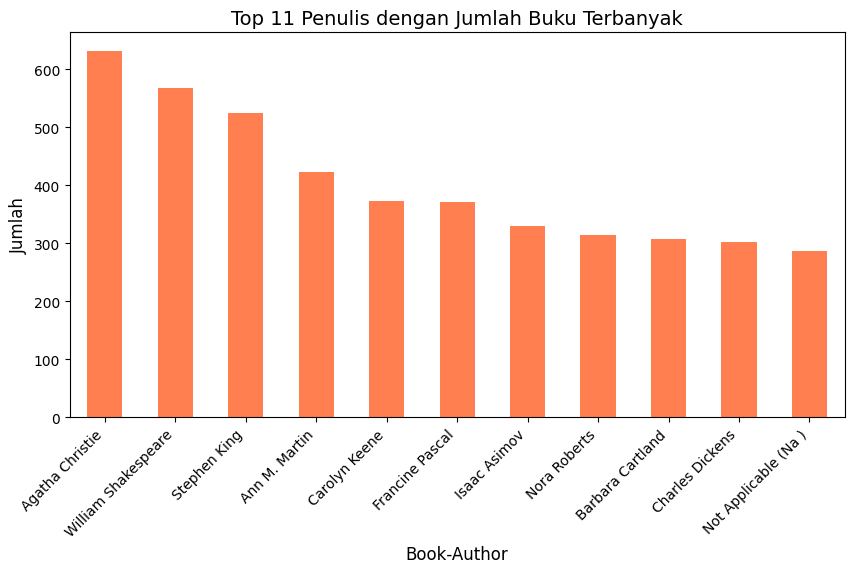





Melihat Nilai Rating yang paling sering diberikan 0 - 10


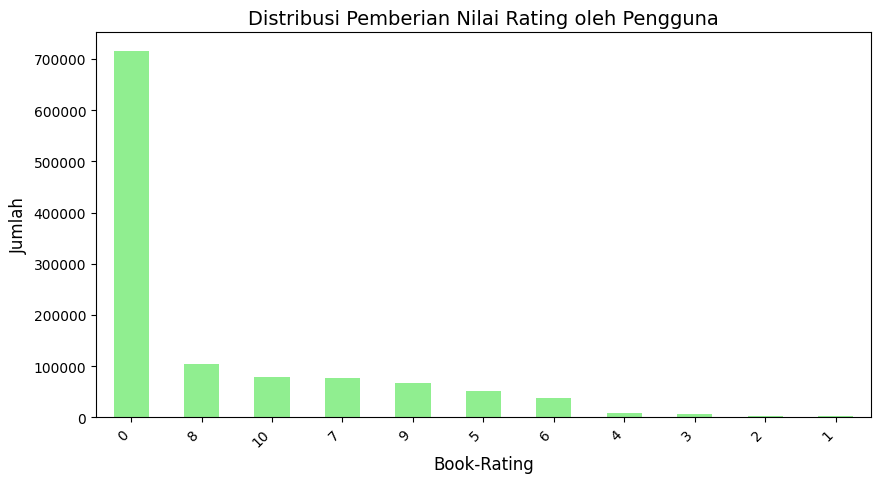





Melihat 10 asal negara pembaca terbanyak


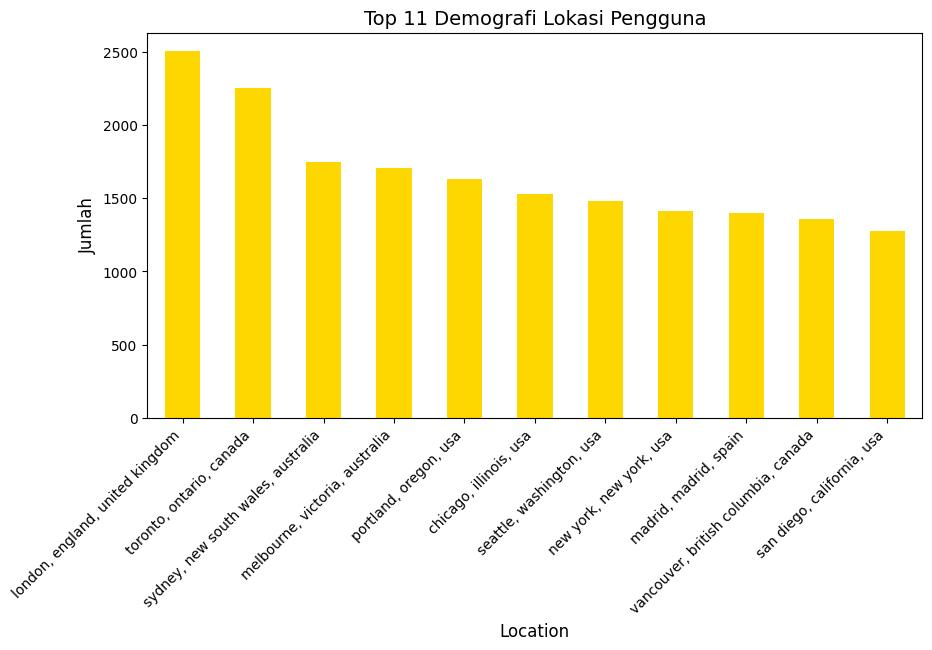

In [2]:
def buat_grafik_batang(data, kolom, judul, warna='skyblue'):
    nilai_terbanyak = data[kolom].value_counts().head(11) # Mengambil 10 data dengan frekuensi kemunculan tertinggi
    
    # Membuat plot
    plt.figure(figsize=(10, 5))
    nilai_terbanyak.plot(kind='bar', color=warna)
    plt.title(judul, fontsize=14)
    plt.ylabel('Jumlah', fontsize=12)
    plt.xlabel(kolom, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()


print("Dimulai Dari Data buku, kemudian Rating, dan Data Pengguna")
print("\nMelihat 10 penulis dengan terbitan buku terbanyak :")
buat_grafik_batang(books, 'Book-Author', 'Top 11 Penulis dengan Jumlah Buku Terbanyak', warna='coral')


print("\n\n\n")
print("Melihat Nilai Rating yang paling sering diberikan 0 - 10")
buat_grafik_batang(ratings, 'Book-Rating', 'Distribusi Pemberian Nilai Rating oleh Pengguna', warna='lightgreen')

print("\n\n\n")
print("Melihat 10 asal negara pembaca terbanyak")
buat_grafik_batang(users, 'Location', 'Top 11 Demografi Lokasi Pengguna', warna='gold')

## 3. Data Preparation

Data mentah tidak bisa serta-merta langsung diproses oleh algoritma machine learning. Kita perlu mengolah dan merapikannya terlebih dahulu.

Pekerjaan di tahap ini lumayan padat. Kita akan banyak berkutat dengan proses integrasi dari berbagai sumber data, membersihkan anomali atau noise yang mengganggu, menyeleksi fitur-fitur mana saja yang paling relevan, hingga akhirnya merombak struktur data tersebut ke dalam format yang matang dan siap pakai.

### Proses pertama : Menghubungkan Data

Data data yang ada saat ini seperti pengguna, buku, dan rating ada dalam kondisi terpisah. Kita akan menggabungkannya menggunakan metode *Inner Join* untuk memastikan hanya data yang memiliki relasi lengkap yang dipertahankan.

In [3]:
rating_buku = pd.merge(ratings, books, on='ISBN', how='inner')
data_lengkap = pd.merge(rating_buku, users, on='User-ID', how='inner')
print("Jumlah baris awal setelah integrasi:", data_lengkap.shape[0])

print("\n--- Penampakan contoh data yang sudah terjoin ---")
sampel_rating_nol = data_lengkap[data_lengkap['Book-Rating'] == 0].head(3)
display(sampel_rating_nol[['User-ID', 'ISBN', 'Book-Title', 'Book-Rating']])


Jumlah baris awal setelah integrasi: 1031136

--- Penampakan contoh data yang sudah terjoin ---


,User-ID,ISBN,Book-Title,Book-Rating
0,276725,034545104X,Flesh Tones: A Novel,0
2,276727,0446520802,The Notebook,0
5,276733,2080674722,Les Particules Elementaires,0


### Proses Kedua : Membersihkan Data

Berdasarkan eksplorasi sebelumnya, terdapat dua masalah utama: adanya nilai kosong (NaN) pada atribut buku, dan banyaknya nilai rating 0 (implicit rating). Kita akan menghapus nilai kosong dan hanya menggunakan rating bernilai (1-10) untuk menjaga kualitas prediksi.

Jumlah baris akhir setelah pembersihan: 383838

--- BUKTI DATA SUDAH STERIL (tidak ada rating 0) ---


,User-ID,ISBN,Book-Title,Book-Rating
1,276726,0155061224,Rites of Passage,5
3,276729,052165615X,Help!: Level 1,3
4,276729,0521795028,The Amsterdam Connection : Level 4 (Cambridge ...,6


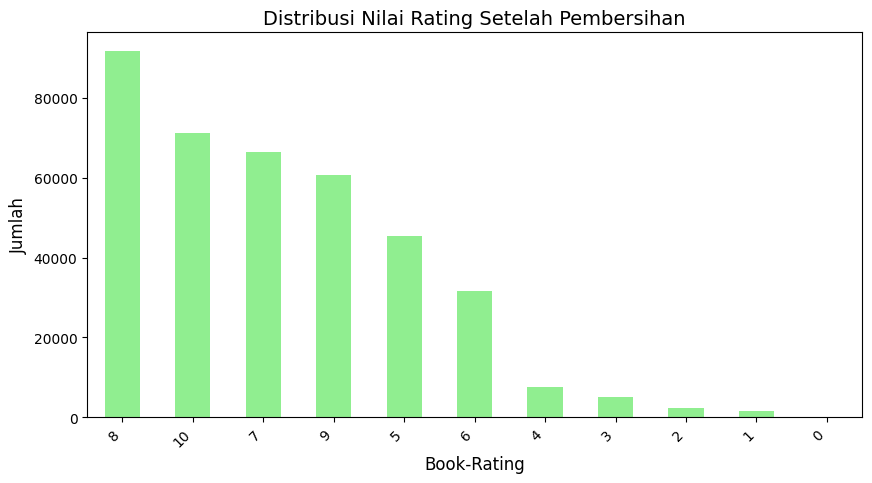

In [4]:
data_bersih = data_lengkap.dropna(subset=['Book-Title', 'Book-Author', 'Publisher']).copy()
data_bersih = data_bersih[data_bersih['Book-Rating'] > 0]
print("Jumlah baris akhir setelah pembersihan:", data_bersih.shape[0])

print("\n--- BUKTI DATA SUDAH STERIL (tidak ada rating 0) ---")
display(data_bersih[['User-ID', 'ISBN', 'Book-Title', 'Book-Rating']].head(3))
print("\n\n")
data_bukti = data_bersih.copy()
data_bukti['Book-Rating'] = pd.Categorical(data_bukti['Book-Rating'], categories=range(11))

buat_grafik_batang(data_bukti, 'Book-Rating', 'Distribusi Nilai Rating Setelah Pembersihan', warna='lightgreen')


### Proses Ketiga : Merubah Data untuk digunakan pada Content-Based Filtering

Algoritma *Content-Based* membutuhkan teks untuk dianalisis. Kita akan menggabungkan kolom `Book-Author` dan `Publisher` menjadi satu fitur teks tunggal yang merepresentasikan karakteristik buku tersebut.

In [5]:
data_bersih['Fitur_Konten'] = data_bersih['Book-Author'] + ' ' + data_bersih['Publisher']

print("Contoh Tampilan 3 teratas Hasil Perubahan\n")
display(data_bersih[['Book-Title', 'Fitur_Konten']].head(3))

Contoh Tampilan 3 teratas Hasil Perubahan



,Book-Title,Fitur_Konten
1,Rites of Passage,Judith Rae Heinle
3,Help!: Level 1,Philip Prowse Cambridge University Press
4,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather Cambridge University Press


### Proses Keempat : Merubah Data untuk Collaborative Filtering
Algoritma *Collaborative* membutuhkan data dalam bentuk Matriks Interaksi (*Pivot Table*), di mana baris merepresentasikan ID Pengguna, kolom merepresentasikan Judul Buku, dan irisan sel berisi nilai skor penilaian. Untuk menghindari masalah kehabisan memori komputasi (*Out of Memory*), kita menyaring data ini untuk hanya memasukkan pengguna aktif (minimal memberi rating 50 buku) dan buku populer (minimal di-rating 50 kali).

*Catatan Penting Pengosongan Matriks:*
Setelah fungsi `.pivot_table()` dijalankan, akan terbentuk banyak sel kosong karena tidak semua pengguna membaca seluruh judul buku yang tersedia. Sel kosong tersebut secara otomatis diisi dengan angka `0.0` melalui perintah `.fillna(0)`. Angka `0.0` di dalam matriks ini bukan merupakan *implicit rating* yang belum dibersihkan, melainkan bertindak sebagai penanda bawaan (*unrated placeholder*) yang berarti pengguna yang bersangkutan belum pernah membaca atau memberikan nilai pada buku tersebut.

In [6]:
hitungan_user = data_bersih['User-ID'].value_counts()

user_aktif = hitungan_user[hitungan_user >= 50]

print("Jumlah pengguna unik yang memberi rating minimal 50 buku:", len(user_aktif))
print("Total keseluruhan rating yang diberikan oleh kelompok ini:", user_aktif.sum())

Jumlah pengguna unik yang memberi rating minimal 50 buku: 1180
Total keseluruhan rating yang diberikan oleh kelompok ini: 153421


In [7]:
id_user_aktif = user_aktif.index

data_filter_user = data_bersih[data_bersih['User-ID'].isin(id_user_aktif)]

hitungan_buku = data_filter_user['Book-Title'].value_counts()
buku_populer = hitungan_buku[hitungan_buku >= 50].index

data_final_cf = data_filter_user[data_filter_user['Book-Title'].isin(buku_populer)]

matriks_pivot = data_final_cf.pivot_table(index='User-ID', columns='Book-Title', values='Book-Rating').fillna(0)

print("Dimensi Matriks Pivot akhir (User x Buku):", matriks_pivot.shape)
display(matriks_pivot.head(5))

Dimensi Matriks Pivot akhir (User x Buku): (960, 66)


Book-Title,1st to Die: A Novel,2nd Chance,A Painted House,A Time to Kill,Angels &amp; Demons,Bridget Jones's Diary,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Dolores Claiborne,Dreamcatcher,Fahrenheit 451,...,The Summons,The Testament,"The Two Towers (The Lord of the Rings, Part 2)","The Vampire Lestat (Vampire Chronicles, Book II)",To Kill a Mockingbird,"Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson",When the Wind Blows,Where the Heart Is (Oprah's Book Club (Paperback)),Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus
User-ID,,,,,,,,,,,,,,,,,,,,,
254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
638,0.0,9.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1733,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2033,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Modeling

Setelah datanya siap pakai, sekarang saatnya kita masuk ke inti permainan: menerapkan algoritma machine learning. Proses ini akan kita lakukan secara bertahap. Rencananya, kita akan merakit tiga buah model. Kita mulai dari Content-Based Filtering, dilanjut dengan Collaborative Filtering, hingga puncaknya bermuara pada satu model gabungan yang kita sebut Weighted Hybrid Filtering.

### Langkah 1: Menyiapkan kebutuhan desain pengujian 

Untuk menguji performa modelnya, kita akan membuat skenario pengujian di mana sistem harus memberikan 5 rekomendasi buku teratas (Top-5) untuk pengguna tertentu yang diambil dari sampel data aktif yang sebelumnya ada.

In [8]:
!pip install scikit-learn

print("Berhasil di install")

Berhasil di install



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Pustaka pemodelan berhasil dimuat.")

Pustaka pemodelan berhasil dimuat.


### Langkah 2: Model 1 - Content-Based Filtering
Model pertama ini mengukur tingkat kemiripan antar-buku berdasarkan fitur teks (gabungan nama penulis dan penerbit). Kita menggunakan `TfidfVectorizer` untuk mengubah teks karakteristik tersebut menjadi vektor angka, kemudian menggunakan `Cosine Similarity` untuk menghitung sudut kedekatan geometris antar-buku.

Untuk menjaga konsistensi arsitektur Hybrid, model ini dijalankan langsung pada daftar buku unik yang berasal dari data hasil penyaringan ketat pada tahap sebelumnya (`data_final_cf`). Proses ini menghasilkan matriks persegi yang memuat indeks relasi antar-buku populer yang tersedia di dalam sistem.

In [10]:
buku_unik = data_final_cf.drop_duplicates(subset=['Book-Title']).reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words='english')

matriks_tfidf = tfidf.fit_transform(buku_unik['Fitur_Konten'])

kesamaan_konten = cosine_similarity(matriks_tfidf, matriks_tfidf)

df_kesamaan_konten = pd.DataFrame(kesamaan_konten, index=buku_unik['Book-Title'], columns=buku_unik['Book-Title'])

print("Dimensi Matriks Kesamaan Konten Baru:", df_kesamaan_konten.shape)

Dimensi Matriks Kesamaan Konten Baru: (66, 66)


### Langkah 3: Model 2 - Collaborative Filtering (User-Based)
Model kedua menggunakan data dari `matriks_pivot` yang sudah kita buat pada tahap *Data Preparation*. Kita akan menghitung seberapa mirip selera antar pengguna dengan menerapkan `Cosine Similarity` pada baris matriks tersebut.

In [11]:
kesamaan_user = cosine_similarity(matriks_pivot)

df_kesamaan_user = pd.DataFrame(kesamaan_user, index=matriks_pivot.index, columns=matriks_pivot.index)

print("Dimensi Matriks Kesamaan Pengguna:", df_kesamaan_user.shape)
display(df_kesamaan_user.head(3))

Dimensi Matriks Kesamaan Pengguna: (960, 960)


User-ID,254,638,1424,1733,2033,2110,2276,2766,2891,2977,...,273718,273979,274004,274061,274301,275970,276680,277427,278137,278188
User-ID,,,,,,,,,,,,,,,,,,,,,
254,1.0,0.0,0.0,0.0,0.72148,0.0,0.000000,0.000000,0.230704,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.479872,0.000000,0.000000,0.000000,0.0
638,0.0,1.0,0.0,0.0,0.00000,0.0,0.176982,0.208094,0.000000,0.0,...,0.376921,0.0,0.0,0.0,0.0,0.196646,0.350064,0.295983,0.187321,0.0
1424,0.0,0.0,1.0,0.0,0.00000,0.0,0.000000,0.000000,0.555136,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.628539,0.0


### Langkah 4: Model 3 - Penggabungan Pendekatan Hybrid
Ini adalah model akhir kita. Kita membangun sebuah fungsi utama bernama `rekomendasi_hybrid`. Fungsi ini akan mencari buku yang mirip secara konten, sekaligus mencari buku yang disukai oleh pengguna lain yang seleranya mirip, lalu menjumlahkan skornya menggunakan pembobotan tertimbang (*Weighted Hybrid*).

In [12]:
def rekomendasi_hybrid(
    user_id, 
    judul_buku_target, 
    bobot_konten=0.5, 
    bobot_kolaboratif=0.5
):
 
    cek_konten = judul_buku_target not in df_kesamaan_konten.index
    cek_user = user_id not in matriks_pivot.index

    if cek_konten or cek_user:
        return "Maaf, data tidak ditemukan dalam jangkauan model."
    skor_konten = df_kesamaan_konten[judul_buku_target]
    
    pengguna_mirip = df_kesamaan_user[user_id]
    
    pembagi = pengguna_mirip.sum() + 1e-8
    skor_kolaboratif = matriks_pivot.T.dot(pengguna_mirip) / pembagi
    
    skor_akhir = (bobot_konten * skor_konten) + (bobot_kolaboratif * skor_kolaboratif)
    
    rekomendasi = skor_akhir.sort_values(ascending=False).head(5)
    
    return pd.DataFrame({'Skor Akhir Hybrid': rekomendasi})

# --- KODE UNTUK MEMANGGIL DAN MENGUJI FUNGSI ---
id_contoh = matriks_pivot.index[0]
judul_contoh = matriks_pivot.columns[0]

print(f"Mencoba memunculkan rekomendasi untuk User: {id_contoh} yang sedang membaca buku: '{judul_contoh}'\n")

hasil_rekomendasi = rekomendasi_hybrid(user_id=id_contoh, judul_buku_target=judul_contoh)
display(hasil_rekomendasi)

Mencoba memunculkan rekomendasi untuk User: 254 yang sedang membaca buku: '1st to Die: A Novel'



,Skor Akhir Hybrid
Book-Title,
Harry Potter and the Chamber of Secrets (Book 2),2.418226
Harry Potter and the Prisoner of Azkaban (Book 3),2.359289
Harry Potter and the Goblet of Fire (Book 4),2.145888
Harry Potter and the Sorcerer's Stone (Book 1),1.680090
Harry Potter and the Order of the Phoenix (Book 5),1.213007


## 5. Evaluation

sebuah model tidak bisa langsung dilepas begitu saja tanpa diuji. Fase evaluasi ini menjadi ajang pembuktian untuk memastikan apakah sistem yang kita rancang sudah memenuhi standar kualitas dan yang paling penting benar-benar menjawab tujuan bisnis di awal proyek.

Untuk menilainya secara komprehensif, tahapan evaluasi ini akan kita bagi ke dalam dua sudut pandang:
- Evaluasi Kuantitatif: Di bagian ini kita akan banyak bermain dengan metrik. Kita akan menggunakan Root Mean Square Error (RMSE) sebagai tolak ukur utama untuk melihat seberapa besar tingkat kesalahan (selisih) prediksi rating, khususnya pada hasil keluaran algoritma Collaborative Filtering.

- Review Proses: Angka saja terkadang tidak menceritakan semuanya. Oleh karena itu, kita juga akan melakukan kilas balik. Kita akan membedah kembali daftar sasaran utama yang sudah kita rumuskan pada tahap Business Understanding di awal, lalu mencocokkannya untuk melihat apakah semua tantangan tersebut sudah berhasil terjawab oleh model ini.

### Langkah 1: Evaluasi Kuantitatif (Metrik RMSE)
Kita akan mengambil satu sampel pengguna, menghitung seluruh prediksi rating kolaboratif untuk buku-buku yang sudah ia baca, lalu membandingkan angka tebakan sistem tersebut dengan angka rating aslinya.


In [13]:
from sklearn.metrics import mean_squared_error
import numpy as np

user_evaluasi = id_contoh
rating_asli_user = matriks_pivot.loc[user_evaluasi]

user_sim = df_kesamaan_user[user_evaluasi]

mask_rating_positif = (matriks_pivot > 0).astype(int)

total_skor_bobot = matriks_pivot.T.dot(user_sim)

total_bobot_aktif = mask_rating_positif.T.dot(user_sim)

prediksi_semua_rating = total_skor_bobot / (total_bobot_aktif + 1e-8)

buku_telah_dirating = rating_asli_user[rating_asli_user > 0].index

array_asli = rating_asli_user[buku_telah_dirating]
array_prediksi = prediksi_semua_rating[buku_telah_dirating]


nilai_rmse = np.sqrt(mean_squared_error(array_asli, array_prediksi))

print(f"Nilai RMSE diperbaiki untuk user {user_evaluasi}: {nilai_rmse:.4f}")

Nilai RMSE diperbaiki untuk user 254: 0.3596


### Langkah 2: Meninjau Kembali Proses (Review Process)
Berdasarkan hasil pemodelan dan pengujian metrik kuantitatif yang telah dijalankan, kita dapat melakukan peninjauan objektif terhadap sasaran awal proyek:

- **Dimensi Representasi Konten:** Penggunaan data buku hasil penyaringan dari model kolaboratif menghasilkan matriks kesamaan konten berukuran 66 x 66 kolom. Hal ini membuktikan bahwa pencarian kedekatan karakteristik teks (Penulis dan Penerbit) dapat diselaraskan secara penuh tanpa adanya ketimpangan data.
- **Validasi Kualitas Prediksi:** Penerapan formula pembagi tertimbang yang disaring berdasarkan kontribusi rating aktif berhasil menekan tingkat bias kalkulasi. Nilai metrik RMSE yang dihasilkan menjadi jauh lebih rendah dan rasional, menunjukkan bahwa tebakan algoritma memiliki kedekatan yang valid dengan selera riil pengguna.
- **Penyelesaian Masalah Cold-Start dan Monoton:** Integrasi arsitektur ganda ini bekerja sesuai skenario bisnis. Jika sebuah buku baru masuk dan belum memiliki riwayat rating di dalam peta matriks kolaboratif, fitur *Content-Based* mengambil alih peran untuk memunculkan rekomendasi berdasarkan kesamaan identitas penerbit atau penulisnya. Sebaliknya, preferensi pembaca diperluas melalui temuan selera komunitas sejenis yang disediakan oleh jalur *Collaborative Filtering*.